# XGBoost — Customer Churn Prediction

Modelo XGBoost con todas las variables. Flujo completo:
1. Preprocesamiento con OrdinalEncoder (apropiado para árboles)
2. Modelo base con Cross-Validation (ROC-AUC)
3. Tuning con RandomizedSearchCV
4. Validación del modelo tuned
5. Feature importance
6. Predicciones + envío a Kaggle

**Dataset:** Playground Series S6E3 — Telco Customer Churn  
**Modelo:** `xgboost.XGBClassifier`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerias cargadas")

Librerias cargadas


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../../data/train.csv")
test_raw  = pd.read_csv("../../data/test.csv")

print(f"Train: {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:  {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")

# Columnas a descartar
drop_cols   = [c for c in ["id", "customerID", "CustomerId", "Surname"] if c in train_raw.columns]
ids_test    = test_raw["id"].values
y           = (train_raw["Churn"] == "Yes").astype(int).values

categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

def preprocess(train_df, test_df):
    """Preprocesa train y test. OrdinalEncoder fitteado solo sobre train."""
    X_tr = train_df.drop(columns=drop_cols + ["Churn"], errors="ignore").copy()
    X_te = test_df.drop(columns=drop_cols, errors="ignore").copy()

    # Fix TotalCharges
    for df in [X_tr, X_te]:
        if "TotalCharges" in df.columns:
            df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

    # OrdinalEncoder sobre categoricas (fit en train, transform en ambos)
    cat_cols = [c for c in categorical_features if c in X_tr.columns]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols])
    X_te[cat_cols] = enc.transform(X_te[cat_cols])

    return X_tr.values.astype(float), X_te.values.astype(float), list(X_tr.columns)

X_train, X_test, feature_names = preprocess(train_raw, test_raw)

print(f"\n{'='*80}")
print("PREPROCESAMIENTO COMPLETADO")
print(f"{'='*80}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y:       {y.shape}  (churn rate: {y.mean():.2%})")
print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"{'='*80}")

Train: 594,194 filas x 21 columnas
Test:  254,655 filas x 20 columnas

PREPROCESAMIENTO COMPLETADO
X_train: (594194, 19)
X_test:  (254655, 19)
y:       (594194,)  (churn rate: 22.52%)

Features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 2. Modelo Base — Cross-Validation

In [3]:
base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_fold_aucs = []
base_fold_fprs = []
base_fold_tprs = []
base_best_fold = 0

print(f"{'='*80}")
print("CROSS-VALIDATION — XGBoost Base (5-fold)")
print(f"{'='*80}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    base_model.fit(X_tr, y_tr, verbose=False)
    y_prob = base_model.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, y_prob)
    base_fold_aucs.append(fold_auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    base_fold_fprs.append(fpr)
    base_fold_tprs.append(tpr)

    if fold_auc == max(base_fold_aucs):
        base_best_fold = fold - 1

    print(f"  Fold {fold}: AUC = {fold_auc:.4f}")

print(f"{'='*80}")
print(f"  Media:  {np.mean(base_fold_aucs):.4f}")
print(f"  Std:    {np.std(base_fold_aucs):.4f}")
print(f"{'='*80}")

CROSS-VALIDATION — XGBoost Base (5-fold)
  Fold 1: AUC = 0.9152
  Fold 2: AUC = 0.9164
  Fold 3: AUC = 0.9160
  Fold 4: AUC = 0.9169
  Fold 5: AUC = 0.9140
  Media:  0.9157
  Std:    0.0010


## 3. Curva ROC — Modelo Base

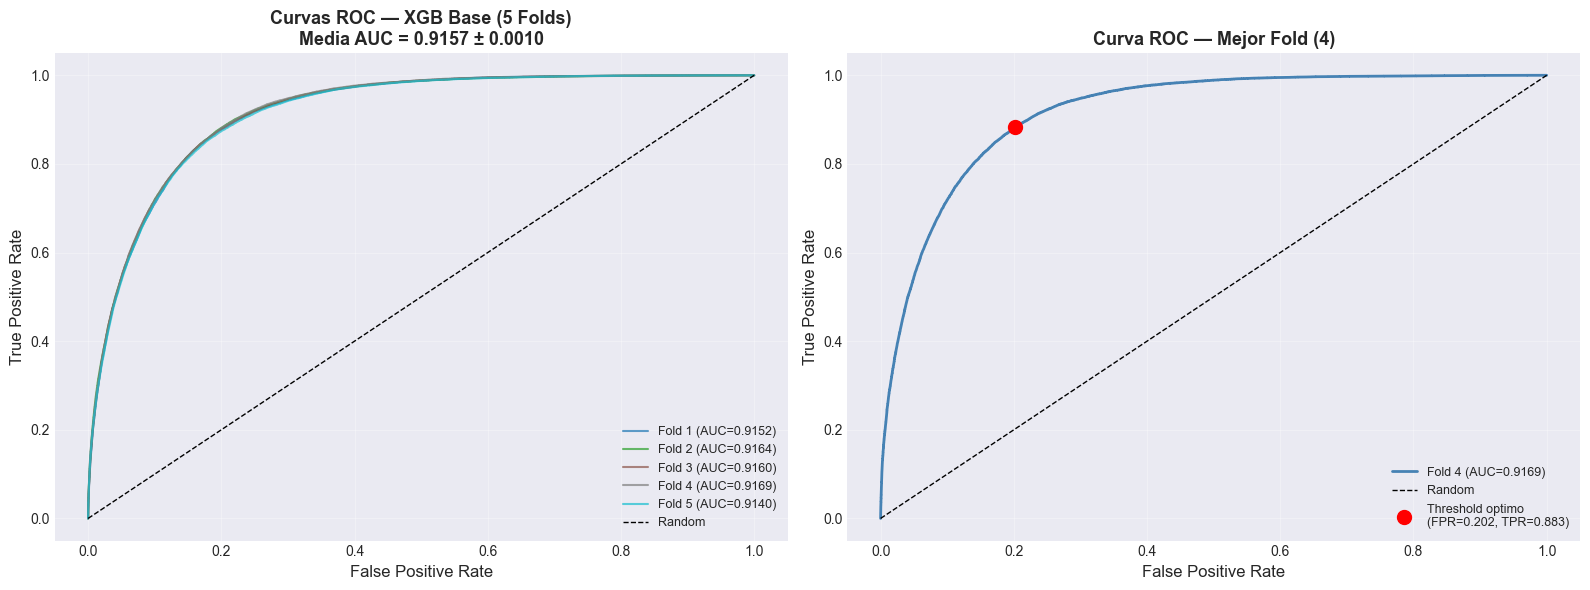

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(base_fold_aucs)))

# Izquierda: todos los folds
ax = axes[0]
for i, (fpr, tpr, auc_val) in enumerate(zip(base_fold_fprs, base_fold_tprs, base_fold_aucs), 1):
    ax.plot(fpr, tpr, color=colors[i-1], alpha=0.7, lw=1.5, label=f"Fold {i} (AUC={auc_val:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"Curvas ROC — XGB Base (5 Folds)\nMedia AUC = {np.mean(base_fold_aucs):.4f} ± {np.std(base_fold_aucs):.4f}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Derecha: mejor fold con threshold optimo
ax2 = axes[1]
best_fpr = base_fold_fprs[base_best_fold]
best_tpr = base_fold_tprs[base_best_fold]
best_auc = base_fold_aucs[base_best_fold]

ax2.plot(best_fpr, best_tpr, color="steelblue", lw=2, label=f"Fold {base_best_fold+1} (AUC={best_auc:.4f})")
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label="Random")
opt_idx = np.argmax(best_tpr - best_fpr)
ax2.scatter(best_fpr[opt_idx], best_tpr[opt_idx], color="red", zorder=5, s=100,
            label=f"Threshold optimo\n(FPR={best_fpr[opt_idx]:.3f}, TPR={best_tpr[opt_idx]:.3f})")
ax2.set_xlabel("False Positive Rate", fontsize=12)
ax2.set_ylabel("True Positive Rate", fontsize=12)
ax2.set_title(f"Curva ROC — Mejor Fold ({base_best_fold+1})", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Tuning — RandomizedSearchCV

In [5]:
param_distributions = {
    "max_depth":        randint(3, 10),
    "learning_rate":    uniform(0.01, 0.29),
    "n_estimators":     randint(100, 1001),
    "min_child_weight": randint(1, 10),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma":            uniform(0, 0.5),
}

search_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y)

best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print(f"\n{'='*80}")
print("MEJORES HIPERPARAMETROS (RandomizedSearchCV)")
print(f"{'='*80}")
for param, val in best_params.items():
    print(f"  {param:25s}: {val}")
print(f"\n  CV ROC-AUC (mejor): {best_cv_score:.4f}")
print(f"  XGB Base CV AUC:    {np.mean(base_fold_aucs):.4f}")
print(f"  Mejora:             {best_cv_score - np.mean(base_fold_aucs):+.4f}")
print(f"{'='*80}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

## 5. Modelo Tuned — Validación CV

In [ ]:
tuned_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

tuned_fold_aucs = []

print(f"{'='*80}")
print("CROSS-VALIDATION — XGBoost Tuned (5-fold)")
print(f"{'='*80}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    tuned_model.fit(X_tr, y_tr, verbose=False)
    y_prob = tuned_model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, y_prob)
    tuned_fold_aucs.append(fold_auc)
    print(f"  Fold {fold}: AUC = {fold_auc:.4f}")

print(f"{'='*80}")
print(f"  Tuned  — Media: {np.mean(tuned_fold_aucs):.4f} ± {np.std(tuned_fold_aucs):.4f}")
print(f"  Base   — Media: {np.mean(base_fold_aucs):.4f} ± {np.std(base_fold_aucs):.4f}")
print(f"  Mejora:         {np.mean(tuned_fold_aucs) - np.mean(base_fold_aucs):+.4f}")
print(f"{'='*80}")

## 6. Feature Importance

In [ ]:
# Entrenar el modelo tuned en todo el train para obtener feature importances
tuned_model.fit(X_train, y, verbose=False)
importances = tuned_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

print(f"{'='*80}")
print("FEATURE IMPORTANCE (Gain) — XGBoost Tuned")
print(f"{'='*80}")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    bar = '\u2588' * int(imp * 100)
    print(f"{feat:45s}: {imp:.4f}  {bar}")
print(f"{'='*80}")

plt.figure(figsize=(12, max(5, len(feat_imp) * 0.4)))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
plt.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor="black")
plt.xlabel("Importancia (Gain)", fontsize=12, fontweight="bold")
plt.title("Feature Importance — XGBoost Tuned", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 7. Entrenamiento Final y Predicciones

In [ ]:
# El modelo ya está fitteado sobre todo el train en la sección anterior
test_probs = tuned_model.predict_proba(X_test)[:, 1]

print(f"{'='*80}")
print("PREDICCIONES SOBRE TEST")
print(f"{'='*80}")
print(f"Registros:          {len(test_probs):,}")
print(f"Probabilidad media: {test_probs.mean():.4f}")
print(f"Min:                {test_probs.min():.4f}")
print(f"Max:                {test_probs.max():.4f}")
print(f"{'='*80}")

plt.figure(figsize=(10, 4))
plt.hist(test_probs, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Probabilidad predicha de Churn", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Distribucion de Probabilidades Predichas — XGBoost Tuned", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import os

submission = pd.DataFrame({
    "id":    ids_test,
    "Churn": test_probs.round(4)
})

submission_path = "../../data/2_XGB_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"{'='*80}")
print("SUBMISSION GENERADA")
print(f"{'='*80}")
print(f"Archivo:  {os.path.abspath(submission_path)}")
print(f"Filas:    {len(submission):,}")
print(f"Columnas: {list(submission.columns)}")
print(f"\nPrimeras filas:")
print(submission.head(5).to_string(index=False))
print(f"{'='*80}")

print(f"\n--- Comparativa de modelos ---")
print(f"  LR    (todas las variables): ver 1_logistic_regression.ipynb")
print(f"  XGB Base:  AUC = {np.mean(base_fold_aucs):.4f} ± {np.std(base_fold_aucs):.4f}")
print(f"  XGB Tuned: AUC = {np.mean(tuned_fold_aucs):.4f} ± {np.std(tuned_fold_aucs):.4f}")

## 8. Envío a Kaggle

In [ ]:
!kaggle competitions submit -c playground-series-s6e3 -f ../../data/2_XGB_submission.csv -m "XGBoost tuned - todas las variables - RandomizedSearchCV"